In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml

germinal = pd.read_csv("/home/bri/pymol/EDA/static/germinal_outputs/scores_df_extended_with_chai.csv")
mcmahon = pd.read_csv("/home/bri/pymol/EDA/static/mcmahon_outputs/scores_df_extended_with_chai.csv")
snir = pd.read_csv("/home/bri/pymol/EDA/static/snir_outputs/scores_df_extended_with_chai.csv")
YAML_PATH =  Path("/home/bri/pymol/EDA/static/metric_directions.yaml")
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/rankings")
OUTPUT_DIR.mkdir(exist_ok=True)


print(f"Germinal:\n{germinal['binder'].value_counts()}")
print(f"McMahon:\n{mcmahon['binder'].value_counts()}")
print(f"Snir:\n{snir['binder'].value_counts()}")

#snir.head()

Germinal:
binder
0    456
1     24
Name: count, dtype: int64
McMahon:
binder
0    26
1    19
Name: count, dtype: int64
Snir:
binder
0    32
1     3
Name: count, dtype: int64


In [2]:
import pandas as pd

# 3 specific types
types = {
    (1, "original"): 24,       # Positive
    (0, "original"): 13,       # Hard Negative
    (0, "target_shuffle"): 13  # Easy Negative
}

# other ds
other_combined = pd.concat([mcmahon, snir], axis=0)

combined_iterations = []

for i in range(6): # 10 iterations
    parts = []
    
    # Nested unpacking: (binder, type) comes from the key, n from the value
    for (binder, type), n in types.items():
        
        # Apply both filters to get the specific pool
        subset = germinal[(germinal['binder'] == binder) & 
                          (germinal['type'] == type)]
        
        # Draw n samples from this specific pool
        parts.append(subset.sample(n=n, random_state=i))
    
    # Combine the 3 parts (10+20+20 = 50 rows total per iteration)
    iteration_df = pd.concat(parts).sample(frac=1, random_state=i)
    iteration_df["iteration"] = i

    
    # Add the iteration label to snir/mcmahon
    base_with_label = other_combined.copy()
    base_with_label["iteration"] = i
    
    # combine
    combined_iteration = pd.concat([base_with_label, iteration_df], axis=0)
    
    combined_iterations.append(combined_iteration)

# single large df where each iteration (0-9) 
df = pd.concat(combined_iterations).reset_index(drop=True)
df.to_csv(OUTPUT_DIR / "scores_df_merged_final.csv", index=False)

In [3]:
print(f"Subsampled Germinal:\n{df['source'].value_counts()}")
print(f"Subsampled Germinal:\n{df['binder'].value_counts()}")
print(f"Subsampled Germinal Types:\n{df['type'].value_counts()}")
print(f"Subsampled Germinal:\n{df['iteration'].value_counts()}")

Subsampled Germinal:
source
germinal    300
mcmahon     270
snir_ab     210
Name: count, dtype: int64
Subsampled Germinal:
binder
0    504
1    276
Name: count, dtype: int64
Subsampled Germinal Types:
type
original          402
alanine_scan      192
target_shuffle    186
Name: count, dtype: int64
Subsampled Germinal:
iteration
0    130
1    130
2    130
3    130
4    130
5    130
Name: count, dtype: int64


In [ ]:
cols_to_drop=(['af3_rank', 'af3_ranking_score', 'af3_rank0_masif', 'cf_rank', 'cf_rank0_masif'] #, 'af3_pdockq', 'cf_pdockq', 'chai_unconstrained_pdockq', 'chai_constrained_pdockq', 'boltz_free_pdockq', 'boltz_template_pdockq', 'chai_constrained_per_chain_ptm', 'chai_constrained_interface_iptm', 'chai_unconstrained_interface_iptm', 'chai_constrained_per_chain_iptm', 'chai_unconstrained_per_chain_iptm', 'chai_unconstrained_per_chain_ptm'])  #  

scores_df = df.drop(columns=cols_to_drop)

# vllt drop 'KD[M]', 'EC50[M]' too?
#scores_df.head()

### data transformation

In [ ]:
exclude_cols = ['KD[M]', 'EC50[M]']  # columns to exclude
numeric_cols = scores_df.select_dtypes(include=['number']).columns.tolist()

# Remove excluded columns from numeric_cols
for col in exclude_cols:
    if col in numeric_cols:
        numeric_cols.remove(col)
    

# Remove binder
if 'binder' in numeric_cols:
    numeric_cols.remove('binder')

numeric_cols
len(numeric_cols)  

In [ ]:
# Group metrics by model (?)
model_groups = {
    "af3": [...],
    "cf": [...],
    "esmfold": [...],
    "chai_constrained": [...],
    "chai_unconstrained": [...],
    "boltz_free": [...],
    "boltz_template": [...],
}
models = ['af3', 'cf', 'esmfold', 'chai_constrained', 'chai_unconstrained', 'boltz_free', 'boltz_template']
model_groups = {model: [c for c in numeric_cols if c.startswith(model)] for model in models}

metric_families = {
    "plddt": [
        "af3_plddt",
        "cf_plddt",
        "esmfold_plddt",
        "boltz_free_plddt",
        "boltz_template_plddt",
    ],

    "ptm": [
        "af3_ptm",
        "cf_ptm",
        "esmfold_ptm",
        "chai_unconstrained_ptm",
        "chai_constrained_ptm",
        "boltz_free_ptm",
        "boltz_template_ptm",
    ],

    "iptm": [
        "af3_iptm",
        "cf_iptm",
        "chai_unconstrained_iptm",
        "chai_constrained_iptm",
        "boltz_free_iptm",
        "boltz_template_iptm",
    ],

    "pdockq2": [
        "af3_pdockq2",
        "cf_pdockq2",
        "chai_unconstrained_pdockq2",
        "chai_constrained_pdockq2",
        "boltz_free_pdockq2",
        "boltz_template_pdockq2",
    ],
}


In [ ]:
from sklearn.preprocessing import RobustScaler

meta_cols = ['sample', 'binder', 'source', 'type', 'iteration', 'binder_type']
numeric_cols = [c for c in scores_df.columns if c not in meta_cols]

scaler = RobustScaler()

scores_df_scaled = scores_df.copy()
scores_df_scaled[numeric_cols] = scaler.fit_transform(scores_df[numeric_cols])
scores_df_scaled.head()

long_scores_df = pd.melt(
    scores_df_scaled,
    id_vars=["sample", "binder", "binder_type", "source"],
    value_vars=numeric_cols,
    var_name="metric",
    value_name="value"
)

long_scores_df.head()

In [ ]:
# read metric_directions.yaml (directionality should be +1 for metrics where higher is better, -1 for metrics where lower is better, applied after scaling)

if Path(YAML_PATH).exists():
    with open(YAML_PATH, 'r') as f:
        yaml_data = yaml.safe_load(f)
    
    # Extract directions
    raw_directions = {k: v['direction'] for k, v in yaml_data['metrics'].items()}
    metric_directions = dict(sorted(raw_directions.items(), key=lambda x: len(x[0]), reverse=True))
    print(f"Loaded {len(metric_directions)} metric directions from YAML.")
else:
    print(f"WARNING: YAML not found at {YAML_PATH}. Using default direction (+1).")
    metric_directions = {}

def get_direction(col_name):
    for base_metric, direction in metric_directions.items():
        if base_metric in col_name: 
            return direction
    return 1

In [ ]:
def parse_metric(metric):
    parts = metric.split("_")

    if metric.startswith("chai_"):
        model = "_".join(parts[:2])
        metric_name = "_".join(parts[2:])
    elif metric.startswith("boltz_"):
        model = "_".join(parts[:2])
        metric_name = "_".join(parts[2:])
    else:
        model = parts[0]
        metric_name = "_".join(parts[1:])

    return model, metric_name
long_scores_df[['model', 'metric_family']] = (
    long_scores_df['metric']
    .apply(parse_metric)
    .apply(pd.Series)
)


In [ ]:

# Create the 3-group logic to be able to distuinguish between easy and hard negatives
def categorize_row(row):
    if row['binder'] == 1:
        return 'Binder'
    elif row['type'] == 'original': # binder = 0
        return 'Non-Binder'
    else: # binder = 0 and type = target_shuffle
        return 'Target Shuffle'

scores_df['binder_type'] = scores_df.apply(categorize_row, axis=1)

# Map the colors explicitly to the groups
colors_map = {
    'Binder': '#2ecc71',      # Green
    'Non-Binder': "#67e7dd",  # Aquamarine
    'Target Shuffle': "#273397",       # Blue
    'germinal': "#2ecc71",
    'mcmahon': "#d6a439",
    'snir_ab': "#1f3397"  
}

In [ ]:
sns.catplot(
    data=long_scores_df,
    x='binder_type',
    y='value',
    hue='model',
    col='metric_family',
    kind='box',
)

In [ ]:
# Detailed Separability

import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics
sns.set_theme(style="white")

# Determine if there are multiple classes to compare
has_both_classes = long_scores_df['binder'].nunique() > 1

for model, cols in model_groups.items():
    if not cols: continue
    
    # Filter out columns that are entirely NaN to prevent the "bxp length" error
    valid_cols = [c for c in cols if long_scores_df[c].notna().any()]
    if not valid_cols:
        print(f"Skipping {model.upper()}: No valid numeric data found.")
        continue


    # Calculate grid size
    n_cols = 4
    n_rows = (len(valid_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, col in enumerate(valid_cols):
        ax = axes[i]
        
        # df contains 'binder_type'
        plot_df = long_scores_df.dropna(subset=[col]).copy()

        
        if plot_df.empty:
            continue

        hue_order = sorted(plot_df['source'].unique())
        #x_order = sorted(plot_df['binder'].unique())
        x_order = [
            "Binder",
            "Non-Binder",
            "Target Shuffle"
        ]

        # Stripplot
        sns.stripplot(
            data=plot_df, 
            x='binder_type', 
            y=col, 
            order=x_order,
            hue='source',
            hue_order=hue_order,
            dodge=True,
            jitter=0.1, 
            palette=colors_map,
            size=3,
            ax=ax,
            legend=False 
        )
        
        # Boxplot  ???
        sns.boxplot(
            data=plot_df, 
            x='binder_type', 
            y=col, 
            order=x_order,
            dodge=True,
            showcaps=False, 
            fill=True, 
            hue='source',
            hue_order=hue_order,
            palette=colors_map,
            ax=ax,
            width=0.7,
            zorder=10, 
            showfliers=False,
            legend=False 
        )

        for artist in ax.patches:
            artist.set_alpha(0.5)
        
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Type')
        ax.set_ylabel('Score')

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
        
    plt.suptitle(f"{model.upper()} Sample-Level Distribution & Separability", fontsize=18, y=1.02)
    plt.tight_layout()
    
    # Save output
    save_path = OUTPUT_DIR / f"{model}_separability_scatter.png"
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show() 
    
print(f"Finished generating scatterplots for {model.upper()} group.")

#### Correlation Matrix

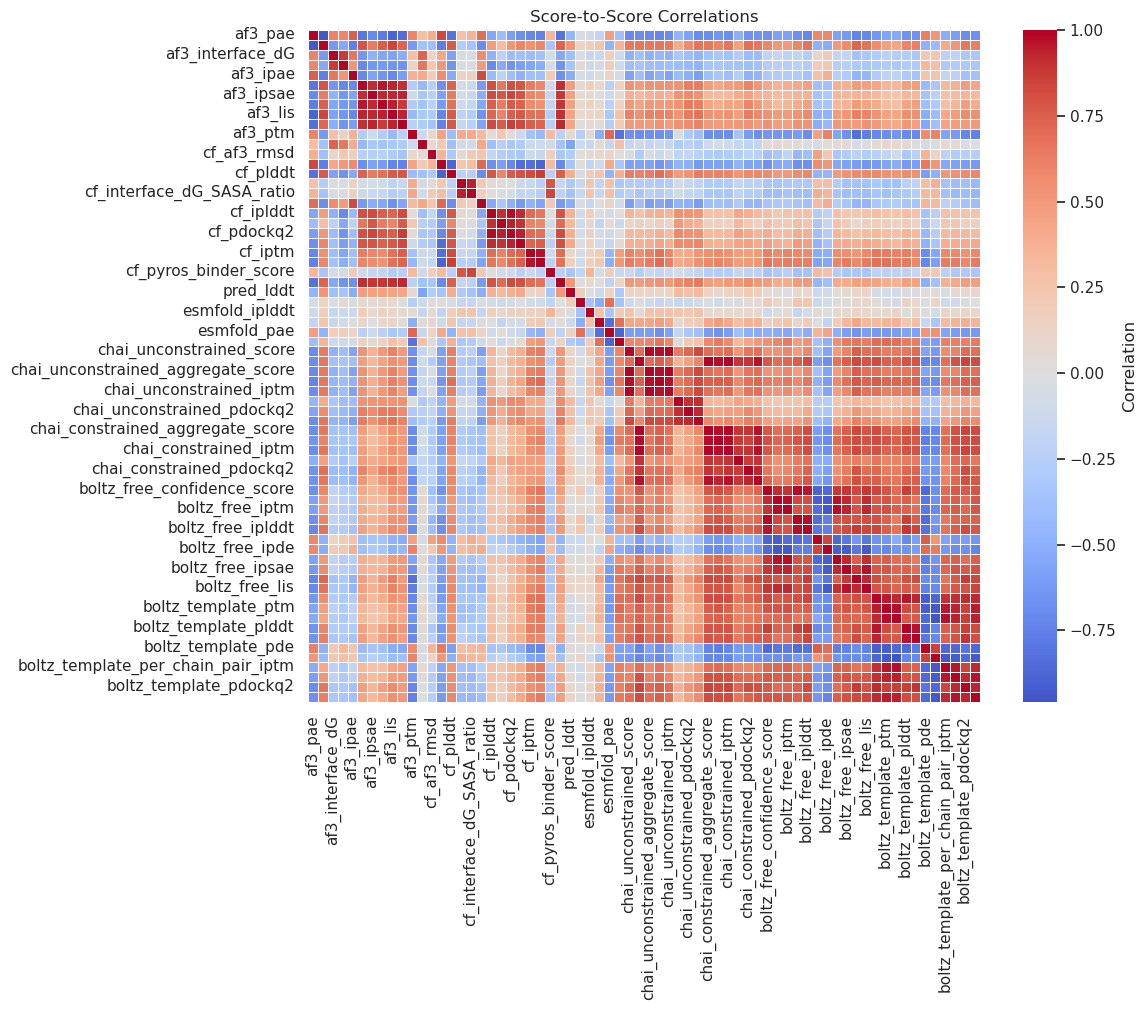

<Figure size 640x480 with 0 Axes>

In [43]:
# directions!!!!!
# Create numeric df and drop binder column
numeric_df = scores_df_scaled.select_dtypes(include=[np.number])
numeric_df = numeric_df.dropna(axis=1, how='all')
numeric_df = numeric_df.drop('binder', axis=1, errors='ignore')
numeric_df = numeric_df.drop('iteration', axis=1, errors='ignore')
numeric_df = numeric_df.drop('KD[M]', axis=1, errors='ignore')
numeric_df = numeric_df.drop('EC50[M]', axis=1, errors='ignore')

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Score-to-Score Correlations')
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / 'score_correlation_heatmap.png', dpi=500, bbox_inches='tight')
